# Semantic Embedding

Builds dense vector representations for all products using a two-tower architecture.

**Architecture:**
```
product_text_base  →  MPNet  →  product_emb  (768-dim)
                                                        →  combined_emb  →  FAISS index
review texts       →  MPNet  →  review_emb   (768-dim)
```

**Key design choices:**
| Choice | Reason |
|---|---|
| all-mpnet-base-v2 | STS benchmark 72.4 vs 68.1 for MiniLM — better semantic quality |
| Two-tower | Respects MPNet's 512-token limit; product and review signals stay separable |
| Weighted review average | 70% of raw reviews are 5-star — plain average is biased |
| Dynamic alpha per product | Products with weak review signal → product embedding dominates |
| Bias correction | Rare reviews (e.g. negative reviews in mostly-positive products) get boosted |
| IndexFlatIP | Exact search; < 5ms for ~7k products; no approximation needed |

**Output files (all in DATA_DIR):**
- `product_embeddings.npy` (n_products, 768)
- `review_embeddings.npy` (n_products, 768)
- `combined_embeddings.npy` (n_products, 768)
- `faiss_index.bin` FAISS IndexFlatIP
- `embedding_index.csv` maps row index → product metadata


## Setup

In [4]:
import os
import sys
sys.path.insert(0, "src")

import time, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
import faiss
from sklearn.decomposition import PCA

from mean_squared_terrors.config import (
    IO_DIR,
    MIN_REVIEW_TOKENS,
    MODEL_NAME, BATCH_SIZE,
    W_HELPFUL, W_RATING,
    ALPHA_MIN, ALPHA_MAX,
)
from mean_squared_terrors.embedding import (
    compute_review_weights, compute_review_embedding,
    compute_dynamic_alpha, blend_embeddings, faiss_search,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = "/content/drive/MyDrive/msb-data"

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"
print(f"Device: {DEVICE}")

Device: cuda


## Load Data

In [5]:
products = pd.read_csv(os.path.join(DATA_DIR, "products_cleaned.csv"))
reviews  = pd.read_csv(os.path.join(DATA_DIR, "reviews_cleaned.csv"))

reviews = reviews[reviews["text"].fillna("").str.split().str.len() >= MIN_REVIEW_TOKENS].reset_index(drop=True)

common   = set(products["parent_asin"]) & set(reviews["parent_asin"])
products = products[products["parent_asin"].isin(common)].reset_index(drop=True)
reviews  = reviews[reviews["parent_asin"].isin(common)].reset_index(drop=True)

print(f"Products : {len(products):,}")
print(f"Reviews  : {len(reviews):,}")

asin_to_idx = {asin: i for i, asin in enumerate(products["parent_asin"])}

Products : 7,604
Reviews  : 131,067


## Model Initialization

In [6]:
print(f"Loading model: {MODEL_NAME}")
t0    = time.time()
model = SentenceTransformer(MODEL_NAME, device=DEVICE)
DIM   = model.get_sentence_embedding_dimension()
print(f"Ready in {time.time()-t0:.1f}s  |  embedding dim={DIM}")


Loading model: all-mpnet-base-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Ready in 21.5s  |  embedding dim=768


## Product Embeddings

Encodes `product_text_base` for all ~7,604 products.
`normalize_embeddings=True` produces L2-normalised vectors so that
inner product equals cosine similarity — required for FAISS IndexFlatIP.


In [7]:
print("Encoding products...")
t0 = time.time()
product_emb = model.encode(
    products["product_text_base"].fillna("").astype(str).tolist(),
    batch_size=BATCH_SIZE, show_progress_bar=True,
    convert_to_numpy=True, normalize_embeddings=True
)
print(f"\nDone in {time.time()-t0:.1f}s  |  shape: {product_emb.shape}")
print(f"Mean norm: {np.linalg.norm(product_emb, axis=1).mean():.4f}")


Encoding products...


Batches:   0%|          | 0/119 [00:00<?, ?it/s]


Done in 61.8s  |  shape: (7604, 768)
Mean norm: 1.0000


## Review Embeddings: Weighted Average

**Step A:** encode each review individually  
**Step B:** compute per-review weights  
**Step C:** compute weighted average per product

**Weight formula:**
```
weight_i = 0.7 × log1p(helpful_vote_i) / max(log1p)
         + 0.3 × |rating_i - 3| / 2
         × bias_correction_i
```

- `helpful_vote` component: community-validated quality signal. log1p prevents
  a review with 5000 votes from dominating all others.
- `rating distance` component: reviews at rating extremes (1 or 5) carry more
  information than neutral reviews (3 stars).
- `bias_correction`: reviews that are rare for their product (e.g. a negative
  review in a mostly-positive product) get a boost factor of up to 3.0×.


In [8]:
print("Encoding individual reviews...")
t0 = time.time()
review_emb_raw = model.encode(
    reviews["text"].fillna("").astype(str).tolist(),
    batch_size=BATCH_SIZE, show_progress_bar=True,
    convert_to_numpy=True, normalize_embeddings=True
)
print(f"Done in {time.time()-t0:.1f}s  |  shape: {review_emb_raw.shape}")


Encoding individual reviews...


Batches:   0%|          | 0/2048 [00:00<?, ?it/s]

Done in 723.9s  |  shape: (131067, 768)


Final weights — min: 0.0000  max: 2.2769  mean: 0.2731


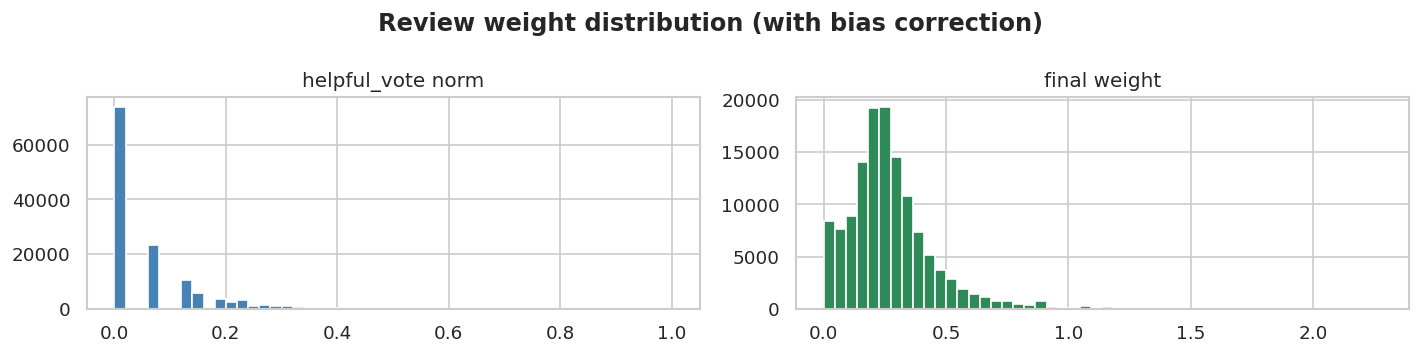

In [9]:
weights_final = compute_review_weights(reviews)

print(f"Final weights — min: {weights_final.min():.4f}  max: {weights_final.max():.4f}  mean: {weights_final.mean():.4f}")

# Weight distribution plot
hv      = reviews["helpful_vote"].fillna(0).values.astype(float)
hv_norm = np.log1p(hv) / (np.log1p(hv).max() or 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
fig.suptitle("Review weight distribution (with bias correction)", fontweight="bold")
axes[0].hist(hv_norm, bins=50, color="steelblue"); axes[0].set_title("helpful_vote norm")
axes[1].hist(weights_final, bins=50, color="seagreen"); axes[1].set_title("final weight")
plt.tight_layout(); plt.show()

In [10]:
review_emb = compute_review_embedding(review_emb_raw, reviews, weights_final, asin_to_idx, DIM)

print(f"Review embedding — shape: {review_emb.shape}")
print(f"Mean norm: {np.linalg.norm(review_emb, axis=1).mean():.4f}")

Review embedding — shape: (7604, 768)
Mean norm: 1.0000


## Dynamic Alpha per Product

Alpha controls the blend between product embedding and review embedding:
```
combined = alpha × product_emb + (1 - alpha) × review_emb
```

Alpha is computed per product based on review signal quality:
- **n_reviews** (normalised, 3→16): more reviews = stronger signal
- **max_helpful_vote** (normalised, 0→20): community validation

Products with `alpha > 0.65` have weak review signals → product text dominates.  
Products with `alpha < 0.45` have strong review signals → review embedding matters more.


Dynamic alpha per product:
  mean=0.560  min=0.350  max=0.732
  Products with alpha < 0.45 (review dominates): 21.1%
  Products with alpha > 0.60 (product dominates):  45.6%


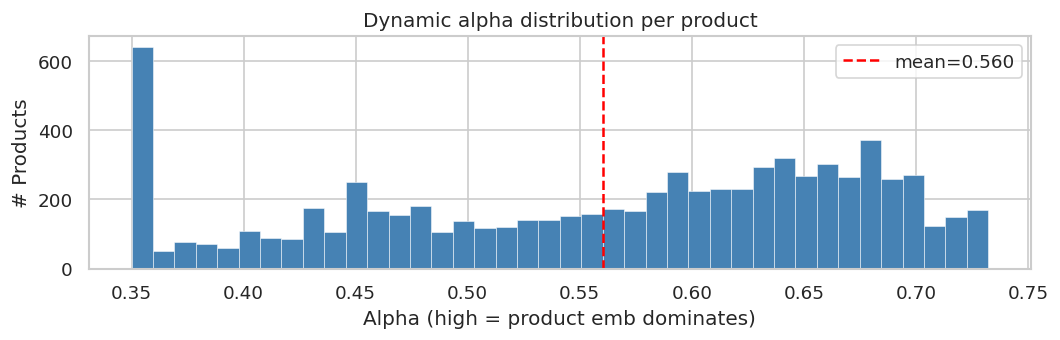

In [11]:
asin_alpha = compute_dynamic_alpha(reviews, products)
alphas = np.array(list(asin_alpha.values()))

print(f"Dynamic alpha per product:")
print(f"  mean={alphas.mean():.3f}  min={alphas.min():.3f}  max={alphas.max():.3f}")
print(f"  Products with alpha < 0.45 (review dominates): {(alphas < 0.45).mean():.1%}")
print(f"  Products with alpha > 0.60 (product dominates):  {(alphas > 0.60).mean():.1%}")

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(alphas, bins=40, color="steelblue", edgecolor="white", linewidth=0.3)
ax.axvline(alphas.mean(), color="red", ls="--", lw=1.5, label=f"mean={alphas.mean():.3f}")
ax.set(title="Dynamic alpha distribution per product",
       xlabel="Alpha (high = product emb dominates)", ylabel="# Products")
ax.legend()
plt.tight_layout(); plt.show()

## Combined Embedding

In [12]:
combined_emb = blend_embeddings(product_emb, review_emb, asin_alpha, products)

print(f"Combined embedding — shape: {combined_emb.shape}")
print(f"Mean norm: {np.linalg.norm(combined_emb, axis=1).mean():.4f}")

Combined embedding — shape: (7604, 768)
Mean norm: 1.0000


## Quality Check

Two checks:
- **PCA 2D**: compress 768 dims to 2 for visualisation — coloured by avg rating
- **Cosine similarity between random pairs**: should be centred near 0,
  meaning products are well-separated in the vector space


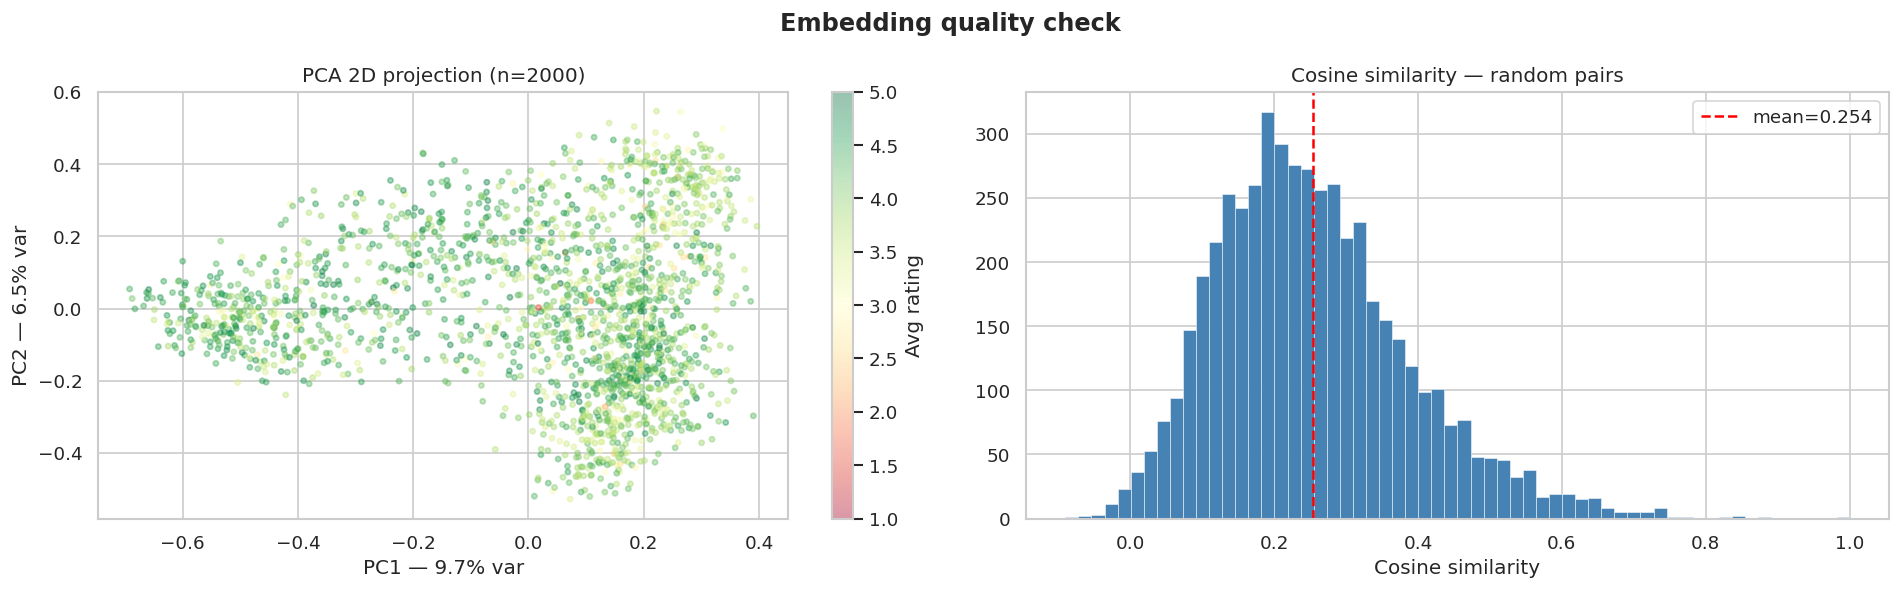

Variance explained PC1+PC2: 16.2%
Mean cosine similarity:   0.254


In [13]:
SAMPLE = min(2000, len(combined_emb))
rng    = np.random.RandomState(42)
sidx   = rng.choice(len(combined_emb), SAMPLE, replace=False)
pca    = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(combined_emb[sidx])
ratings = products["product_avg_rating"].values[sidx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Embedding quality check", fontweight="bold")

sc = axes[0].scatter(emb_2d[:,0], emb_2d[:,1], c=ratings,
                     cmap="RdYlGn", alpha=0.4, s=10, vmin=1, vmax=5)
plt.colorbar(sc, ax=axes[0], label="Avg rating")
axes[0].set_title(f"PCA 2D projection (n={SAMPLE})")
axes[0].set_xlabel(f"PC1 — {pca.explained_variance_ratio_[0]*100:.1f}% var")
axes[0].set_ylabel(f"PC2 — {pca.explained_variance_ratio_[1]*100:.1f}% var")

n_pairs = 5000
ia = rng.randint(0, len(combined_emb), n_pairs)
ib = rng.randint(0, len(combined_emb), n_pairs)
cos = (combined_emb[ia] * combined_emb[ib]).sum(axis=1)
axes[1].hist(cos, bins=60, color="steelblue", edgecolor="white", linewidth=0.3)
axes[1].axvline(cos.mean(), color="red", ls="--", lw=1.5, label=f"mean={cos.mean():.3f}")
axes[1].set_title("Cosine similarity — random pairs")
axes[1].set_xlabel("Cosine similarity")
axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Variance explained PC1+PC2: {pca.explained_variance_ratio_[:2].sum()*100:.1f}%")
print(f"Mean cosine similarity:   {cos.mean():.3f}")


## FAISS Index

Builds an exact inner product index over the combined embeddings.
Self-retrieval test: the first product should find itself at rank 1 with score 1.0.


In [14]:
index = faiss.IndexFlatIP(DIM)
index.add(combined_emb)
print(f"FAISS index — {index.ntotal:,} vectors  |  dim={DIM}")

D, I = index.search(combined_emb[0:1], k=6)
print(f"\nSelf-retrieval test — '{products['product_title'].iloc[0][:55]}...'")
for rank, (score, idx) in enumerate(zip(D[0], I[0])):
    marker = "  <- itself" if idx == 0 else ""
    print(f"  {rank+1}. [{score:.4f}]  {str(products['product_title'].iloc[idx])[:55]}{marker}")


FAISS index — 7,604 vectors  |  dim=768

Self-retrieval test — 'High Potency Magnesium Citrate Capsules 1000mg - Gentle...'
  1. [1.0000]  High Potency Magnesium Citrate Capsules 1000mg - Gentle  <- itself
  2. [0.9694]  High Potency Magnesium Citrate Capsules 1000mg - Gentle
  3. [0.8900]  RnA ReSet - ReMag High Absorption Magnesium Liquid, Exp
  4. [0.8764]  Magnesium Glycinate - High Absorption Mag Supplement fo
  5. [0.8595]  Rising Mag64 Magnesium Chloride with Calcium Tablets 60
  6. [0.8530]  Jigsaw Health Magsrt Magnesium Pack of 2


## Saving Outputs

Saves embeddings as numpy arrays and the FAISS index as a binary file.
Also saves `embedding_index.csv` which maps each FAISS row to product metadata.


In [15]:
np.save(os.path.join(DATA_DIR, "product_embeddings.npy"),  product_emb)
np.save(os.path.join(DATA_DIR, "review_embeddings.npy"),   review_emb)
np.save(os.path.join(DATA_DIR, "combined_embeddings.npy"), combined_emb)
faiss.write_index(index, os.path.join(DATA_DIR, "faiss_index.bin"))

# Save per-product alpha — useful for analysis and debugging
alpha_df = pd.DataFrame({
    "parent_asin": list(asin_alpha.keys()),
    "alpha":       list(asin_alpha.values())
})

bins   = [0, 10, 25, 50, 100, float("inf")]
labels = ["budget","low","mid","high","premium"]
index_df = products[["parent_asin","product_title","brand",
                       "product_avg_rating","product_rating_count","price"]].copy()
index_df = index_df.merge(alpha_df, on="parent_asin", how="left")
index_df["emb_row"]      = range(len(index_df))
index_df["price_bucket"] = pd.cut(index_df["price"], bins=bins, labels=labels)
index_df.to_csv(os.path.join(DATA_DIR, "embedding_index.csv"), index=False)

print("Files saved:")
for fname in ["product_embeddings.npy","review_embeddings.npy",
               "combined_embeddings.npy","faiss_index.bin","embedding_index.csv"]:
    p = os.path.join(DATA_DIR, fname)
    print(f"  {fname:<38}  {os.path.getsize(p)/1e6:.1f} MB")


Files saved:
  product_embeddings.npy                  23.4 MB
  review_embeddings.npy                   23.4 MB
  combined_embeddings.npy                 23.4 MB
  faiss_index.bin                         23.4 MB
  embedding_index.csv                     1.3 MB


## Search Test

Quick end-to-end test of the retrieval pipeline.
Use this to verify that the embeddings are working before running notebook 04.


In [16]:
index_df_loaded = pd.read_csv(os.path.join(DATA_DIR, "embedding_index.csv"))

queries = [
    ("affordable moisturizer for sensitive skin", None),
    ("air purifier quiet bedroom allergies",       None),
    ("cheap sunscreen SPF 50",                    "budget"),
    ("vitamin C supplement immune system",         None),
    ("electric toothbrush whitening",              None),
]

for query, bucket in queries:
    price_filter = f"  [price: {bucket}]" if bucket else ""
    print(f"\n{'─'*68}")
    print(f"Query: '{query}'{price_filter}")
    print('─'*68)
    res = faiss_search(query, model, index, index_df_loaded, k=5, price_bucket=bucket)
    for i, (_, row) in enumerate(res.iterrows()):
        price_str = f"${row['price']:.2f}" if pd.notna(row['price']) else "  N/A"
        alpha  = f"a={row['alpha']:.2f}" if pd.notna(row.get('alpha')) else ""
        title = str(row["product_title"])[:50]
        print(f"  {i+1}. [{row['score']:.4f}] ⭐{row['product_avg_rating']:.1f}"
              f"  {price_str:>8}  {alpha}  {title}")


────────────────────────────────────────────────────────────────────
Query: 'affordable moisturizer for sensitive skin'
────────────────────────────────────────────────────────────────────
  1. [0.5939] ⭐4.6    $16.59  a=0.38  Colonial Dames Concentrated Vitamin E Moisturizing
  2. [0.5924] ⭐3.4       N/A  a=0.66  Sensitive Skin Toner Cucumber Chamomile - Alcohol/
  3. [0.5903] ⭐3.7       N/A  a=0.44  Herbal Choice Mari Tinted SPF30 Face Body Lotion L
  4. [0.5901] ⭐3.7       N/A  a=0.64  Theraplex Emollient Cream Jar, 4.3 Ounce
  5. [0.5853] ⭐4.9     $8.99  a=0.69  Sea Breeze Astringent for Sensitive Skin , 16 Oz

────────────────────────────────────────────────────────────────────
Query: 'air purifier quiet bedroom allergies'
────────────────────────────────────────────────────────────────────
  1. [0.6988] ⭐4.5       N/A  a=0.35  Okaysou Air Purifiers for Home Large Room, Higher 
  2. [0.6740] ⭐4.6       N/A  a=0.35  Okaysou Air Purifiers for Home Large Room with 3 F
  3. [0.6736] 

## ChromaDB Vector Database

Builds a persistent vector database on top of the combined embeddings using **ChromaDB**.

Unlike FAISS (which is an in-memory index rebuilt every session), ChromaDB:
- **Persists to disk**: embeddings are loaded in milliseconds on subsequent runs
- **Supports native metadata filtering**: price bucket and rating filtered inside the DB, not in Python post-hoc
- **Production-ready**: same API works locally or on a remote server

The FAISS index is kept as the primary retrieval engine for search (exact inner product, fast at this scale).
ChromaDB serves as the persistent storage layer and is used when metadata pre-filtering is needed.


In [17]:
try:
    import chromadb
    CHROMA_AVAILABLE = True
except ImportError:
    CHROMA_AVAILABLE = False
    print("ChromaDB not installed — run: pip install chromadb")

if CHROMA_AVAILABLE:
    CHROMA_DIR  = os.path.join(DATA_DIR, "chroma_db")
    COLL_NAME   = "amazon_products"
    BATCH_SIZE  = 2000

    client = chromadb.PersistentClient(path=CHROMA_DIR)

    # Remove existing collection if present (full rebuild every time NB03 runs)
    existing = [c.name for c in client.list_collections()]
    if COLL_NAME in existing:
        client.delete_collection(COLL_NAME)

    collection = client.create_collection(
        name=COLL_NAME,
        metadata={"hnsw:space": "cosine"},
    )

    n = len(index_df)
    print(f"Indexing {n:,} products into ChromaDB (batches of {BATCH_SIZE})...")

    for start in range(0, n, BATCH_SIZE):
        batch = index_df.iloc[start : start + BATCH_SIZE]
        rows  = batch["emb_row"].astype(int).tolist()
        embs  = combined_emb[rows].astype("float32").tolist()

        collection.add(
            ids=batch["parent_asin"].tolist(),
            embeddings=embs,
            metadatas=[
                {
                    "title":        str(row["product_title"])[:500],
                    "price_bucket": str(row.get("price_bucket", "unknown")),
                    "avg_rating":   float(row.get("product_avg_rating", 0) or 0),
                    "price":        float(row.get("price", 0) or 0),
                    "brand":        str(row.get("brand", ""))[:200],
                    "emb_row":      int(row["emb_row"]),
                }
                for _, row in batch.iterrows()
            ],
        )
        print(f"  [{start + len(batch):,}/{n:,}]")

    print(f"\nChromaDB collection '{COLL_NAME}' — {collection.count():,} products")
    print(f"Persisted to: {CHROMA_DIR}")


ChromaDB not installed — run: pip install chromadb


### ChromaDB Search Test

Verifies that ChromaDB returns results consistent with FAISS.
Note: ChromaDB uses cosine *distance* (0 = identical, 2 = opposite);
we convert to similarity = 1 − distance to match FAISS's inner product scores.


In [18]:
if CHROMA_AVAILABLE:
    def chroma_search(query, k=5, price_buckets=None, min_rating=None):
        """Thin wrapper around ChromaDB query — mirrors faiss_search() interface."""
        q_vec = model.encode([query], normalize_embeddings=True,
                             convert_to_numpy=True).astype("float32").tolist()

        # Build metadata filter
        conditions = []
        if price_buckets:
            conditions.append({"price_bucket": {"$in": price_buckets}})
        if min_rating is not None:
            conditions.append({"avg_rating": {"$gte": float(min_rating)}})

        where = None
        if len(conditions) == 1:  where = conditions[0]
        elif len(conditions) > 1: where = {"$and": conditions}

        n_cand = min(k * 6, collection.count())
        result = collection.query(
            query_embeddings=q_vec,
            n_results=n_cand,
            where=where,
            include=["metadatas", "distances"],
        )

        ids   = result["ids"][0]
        dists = result["distances"][0]
        metas = result["metadatas"][0]

        rows = []
        for asin, dist, meta in zip(ids, dists, metas):
            rows.append({
                "parent_asin":       asin,
                "product_title":     meta["title"],
                "price_bucket":      meta["price_bucket"],
                "product_avg_rating": meta["avg_rating"],
                "similarity":        round(1.0 - dist, 4),
            })
        return pd.DataFrame(rows).head(k)

    # --- Comparison: FAISS vs ChromaDB ---
    test_q = "affordable moisturizer for sensitive skin"
    print(f"Query: '{test_q}'")
    print(f"\n{'─'*34} FAISS {'─'*34}")
    faiss_res = faiss_search(test_q, model, index,
                             pd.read_csv(os.path.join(DATA_DIR, "embedding_index.csv")), k=5)
    for i, row in faiss_res.iterrows():
        print(f"  {i+1}. [{row['score']:.3f}]  {str(row['product_title'])[:65]}")

    print(f"\n{'─'*32} ChromaDB {'─'*32}")
    chroma_res = chroma_search(test_q, k=5)
    for i, row in chroma_res.iterrows():
        print(f"  {i+1}. [sim={row['similarity']:.3f}]  {str(row['product_title'])[:65]}")

    # Metadata filter demo
    print(f"\n--- ChromaDB with metadata filter: budget + rating >= 4.0 ---")
    filt_res = chroma_search(test_q, k=5, price_buckets=["budget","low"], min_rating=4.0)
    for i, row in filt_res.iterrows():
        print(f"  {i+1}. [{row['price_bucket']} | {row['product_avg_rating']}★]  "
              f"{str(row['product_title'])[:55]}")
